Using device: cpu
Завантажуємо squirrel.jpg з GitHub...
squirrel.jpg успішно завантажено.

Почали Частину 1 – Імпорт моделі та створення конвеєра


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/45 [00:00<?, ?it/s]

Збережено: squirrel_wizard.png

── Виведення результатів ──
Збережено загальний грід: all_results_grid.png

=== Загальний грід усіх згенерованих зображень ===
[ Squirrel with nut | Cat girl | Source squirrel | Squirrel wizard ]


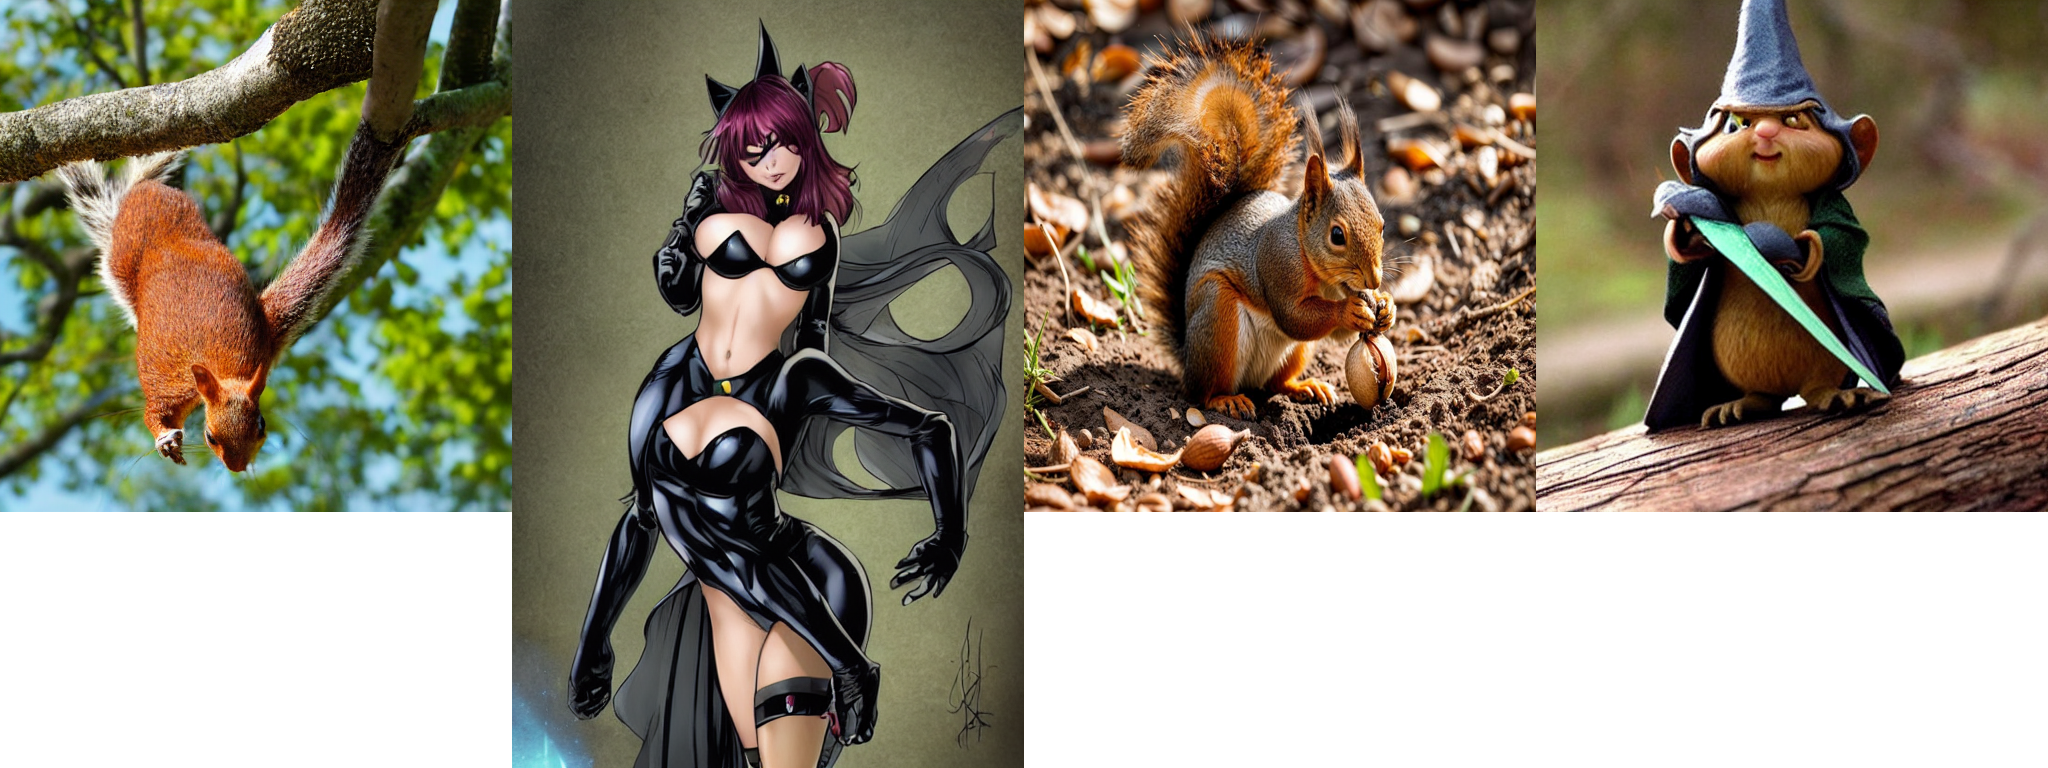


=== Частина 2: Білка з горішком на дереві ===


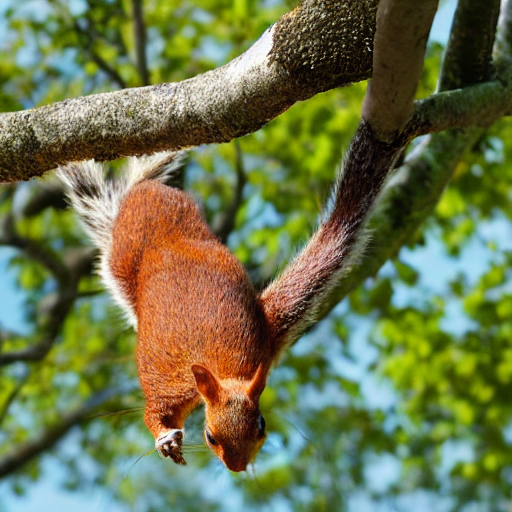


=== Частина 3: Кішко-дівчина (cat girl from batman) ===


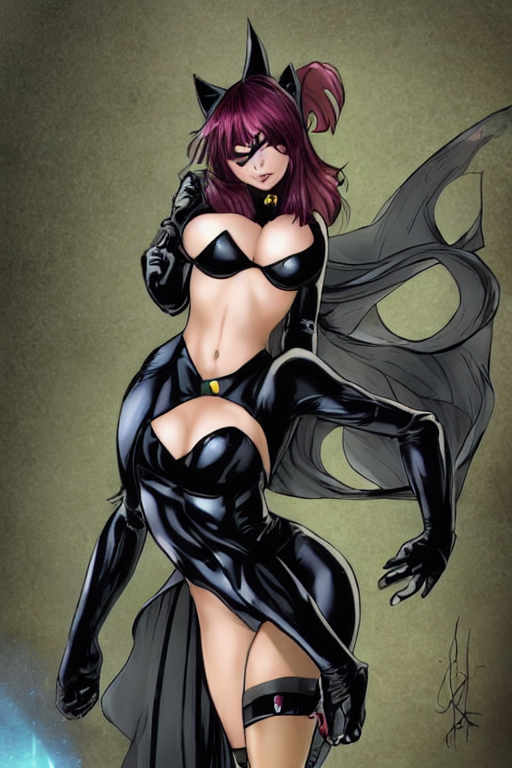


=== Частина 4: Image-to-Image — вхідне зображення vs Squirrel Wizard ===


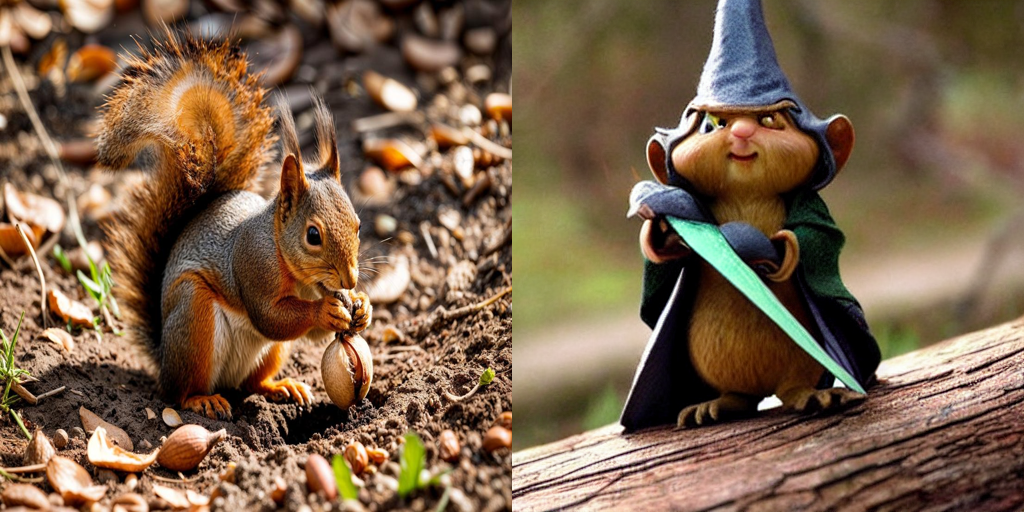


Готово! Усі результати збережено в: /kaggle/working/lab08/output/


In [4]:
import os
import gc
import requests
import torch
from diffusers import StableDiffusionPipeline
from diffusers import StableDiffusionImg2ImgPipeline   # avoids AutoPipeline → HunyuanDiT → MT5Tokenizer crash
from diffusers.utils import make_image_grid, load_image
from diffusers.pipelines.stable_diffusion import safety_checker
from PIL import Image
from IPython.display import display, Image as IPImage

# ──────────────────────────────────────────────────────────────────────────────────
# Лабораторна робота №8 - Генерування зображень за допомогою Stable Diffusion v1-5
# ──────────────────────────────────────────────────────────────────────────────────

ABSOLUTE_PATH = os.getcwd()
LAB_PATH = ABSOLUTE_PATH + "/lab08/"

if not os.path.exists(LAB_PATH + "output"):
    os.makedirs(LAB_PATH + "output")

# ── Kaggle: CUDA GPU; fallback to CPU ────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ── Download source squirrel image from GitHub ───────────────────────────────────
SQUIRREL_RAW_URL = (
    "https://raw.githubusercontent.com/"
    "YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/"
    "main/lab08/squirrel.jpg"
)
squirrel_local_path = LAB_PATH + "squirrel.jpg"

if not os.path.exists(squirrel_local_path):
    print("Завантажуємо squirrel.jpg з GitHub...")
    response = requests.get(SQUIRREL_RAW_URL, timeout=30)
    response.raise_for_status()
    with open(squirrel_local_path, "wb") as f:
        f.write(response.content)
    print("squirrel.jpg успішно завантажено.")
else:
    print("squirrel.jpg вже існує, пропускаємо завантаження.")

# ──────────────────────────────────────────────────────────────────────────────────
# ────────────── Частина 1 – Імпорт моделі та створення конвеєра ───────────────────
# ──────────────────────────────────────────────────────────────────────────────────
print("\nПочали Частину 1 – Імпорт моделі та створення конвеєра")
model_id = "runwayml/stable-diffusion-v1-5"

def sc(self, clip_input, images):
    return images, [False for i in images]

# edit the StableDiffusionSafetyChecker class so that, when called, it just returns the images and an array of True values
safety_checker.StableDiffusionSafetyChecker.forward = sc

# Kaggle: float16 for GPU efficiency (original used float32 for Apple MPS stability)
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    requires_safety_checker=False,
    safety_checker=None
).to(device)

pipe.safety_checker = lambda images, clip_input: (images, [False] * len(images))
pipe.requires_safety_checker = False

# ──────────────────────────────────────────────────────────────────────────────────
# ── Частина 2 – Створення зображення за промтом "Білка з горішком на дереві" ──────
# ──────────────────────────────────────────────────────────────────────────────────
print("\nПочали Частину 2 – Створення зображення за промтом 'Білка з горішком на дереві'")
prompt = "squirrel with a nut on tree"
image_squirrel = pipe(prompt).images[0]

image_squirrel.save(LAB_PATH + "output/squirrel_with_nut.png")
print("Збережено: squirrel_with_nut.png")

# Clear GPU cache after generation
if device == "cuda":
    torch.cuda.empty_cache()
gc.collect()

# ──────────────────────────────────────────────────────────────────────────────────
# Частина 3 – Створення зображення за промтом "Кішко-дівчина" ──────────────────────
#  ─────────  з кількома параметрами:  ─────────────────────────────────────────────
#  ───────────  • height, width  — розмір у пікселях (кратний 8)  ──────────────────
#  ───────────  • guidance_scale — наскільки точно слідувати промту  ───────────────
#  ───────────  • negative_prompt — що модель НЕ повинна малювати  ─────────────────
# ──────────────────────────────────────────────────────────────────────────────────
print("\nПочали Частину 3 – Створення зображення за промтом 'Кішко-дівчина'")
prompt = "cat girl from batman"
negative_prompt = "dog, man, strong"
image_cat_girl = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    guidance_scale=6,
    height=768,
    width=512
).images[0]

image_cat_girl.save(LAB_PATH + "output/cat_girl.png")
print("Збережено: cat_girl.png")

# Clear GPU cache after generation
if device == "cuda":
    torch.cuda.empty_cache()
gc.collect()

# Free text-to-image pipeline before loading image-to-image pipeline
del pipe
if device == "cuda":
    torch.cuda.empty_cache()
gc.collect()

# ──────────────────────────────────────────────────────────────────────────────────
# ────────── Частина 4 – Створення зображення на основі іншого зображення ──────────
# ────────────────  (Image-to-Image)   ─────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────────
print("\nПочали Частину 4 – Створення зображення на основі іншого зображення")

pipeline = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    use_safetensors=True,
    requires_safety_checker=False,
    safety_checker=None,
).to(device)

pipeline.safety_checker = lambda images, clip_input: (images, [False] * len(images))
pipeline.requires_safety_checker = False
pipeline.enable_attention_slicing()

# Важливо: Переводимо в RGB та змінюємо розмір на кратний 8.
# Для Stable Diffusion ідеально підходить 512x512.
init_image = load_image(squirrel_local_path).convert("RGB").resize((512, 512))

prompt = "squirrel wizard, lord of the rings, detailed, fantasy, cute, adorable, Pixar, Disney"

image_wizard = pipeline(
    prompt=prompt,
    image=init_image,
    strength=0.9,            # нижче ніж 0.8 — краще зберігає структуру
    num_inference_steps=50,  # stable-diffusion-v1-5 краще працює за 50
).images[0]

grid_image = make_image_grid(images=[init_image, image_wizard], rows=1, cols=2)
grid_image.save(LAB_PATH + "output/squirrel_wizard.png")
print("Збережено: squirrel_wizard.png")

# Clear GPU cache after generation
if device == "cuda":
    torch.cuda.empty_cache()
gc.collect()

del pipeline
if device == "cuda":
    torch.cuda.empty_cache()
gc.collect()

# ──────────────────────────────────────────────────────────────────────────────────
# ─────────────────── Виведення результатів у Kaggle notebook ──────────────────────
# ──────────────────────────────────────────────────────────────────────────────────
print("\n── Виведення результатів ──")

# Helper: pad image to a target height with white background (for the combined grid)
def pad_to_height(img: Image.Image, target_h: int) -> Image.Image:
    """Pads image vertically with white so it matches target_h."""
    if img.height == target_h:
        return img
    new_img = Image.new("RGB", (img.width, target_h), (255, 255, 255))
    new_img.paste(img, (0, 0))
    return new_img

# Resize for the combined grid so widths are normalised (keep aspect ratio)
THUMB_W = 512

def resize_keep_ratio(img: Image.Image, width: int) -> Image.Image:
    ratio = width / img.width
    return img.resize((width, int(img.height * ratio)), Image.LANCZOS)

thumb_squirrel   = resize_keep_ratio(image_squirrel, THUMB_W)   # 512×512
thumb_cat_girl   = resize_keep_ratio(image_cat_girl, THUMB_W)   # 512×768  → 512×768
thumb_init       = resize_keep_ratio(init_image, THUMB_W)       # 512×512
thumb_wizard     = resize_keep_ratio(image_wizard, THUMB_W)     # 512×512

# Uniform height for the grid row
max_h = max(thumb_squirrel.height, thumb_cat_girl.height,
            thumb_init.height,     thumb_wizard.height)

row = [
    pad_to_height(thumb_squirrel, max_h),
    pad_to_height(thumb_cat_girl, max_h),
    pad_to_height(thumb_init,     max_h),
    pad_to_height(thumb_wizard,   max_h),
]

# Combine all into one wide grid image
total_w = sum(img.width for img in row)
big_grid = Image.new("RGB", (total_w, max_h), (255, 255, 255))
x_offset = 0
for img in row:
    big_grid.paste(img, (x_offset, 0))
    x_offset += img.width

big_grid_path = LAB_PATH + "output/all_results_grid.png"
big_grid.save(big_grid_path)
print("Збережено загальний грід: all_results_grid.png")

# ── Show the big combined grid ─────────────────────────────────────────────────
print("\n=== Загальний грід усіх згенерованих зображень ===")
print("[ Squirrel with nut | Cat girl | Source squirrel | Squirrel wizard ]")
display(big_grid)

# ── Show each image separately ────────────────────────────────────────────────
print("\n=== Частина 2: Білка з горішком на дереві ===")
display(image_squirrel)

print("\n=== Частина 3: Кішко-дівчина (cat girl from batman) ===")
display(image_cat_girl)

print("\n=== Частина 4: Image-to-Image — вхідне зображення vs Squirrel Wizard ===")
display(grid_image)   # the side-by-side grid saved earlier (init vs wizard)

print("\nГотово! Усі результати збережено в:", LAB_PATH + "output/")